In [1]:
include("BarrierSynthesis.jl")

get_random_multi (generic function with 1 method)

# 0. Init system variable and parameters

In [ ]:
#init state and input variables
@polyvar u[1:2]
@polyvar(x[1:7]) # x[1] is x, x[2] is y, x[3] is vel_x, x[4] is vel_y, x[5] is θ, x[6] is ω, x[7] is error

#define system dynamics
dynamics = [
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(-2.0/π)*(x[5]+π)-0.2x[7], (ctrl[1]+ctrl[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(2.0/π)*x[5]+0.2x[7], (ctrl[1]+ctrl[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(2.0/π)*x[5]+0.2x[7], (ctrl[1]+ctrl[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(-2.0/π)*(x[5]-π)-0.2x[7], (ctrl[1]+ctrl[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
    ]

#define unsafe set (obstacle)
g = 0.1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin

#state and input bounds
bounds = [[-20., 20.], [-20., 20.], [-20.,20.], [-20.,20.],[-π,π], [-20.,20.],[-1.,1.]]

7-element Vector{Vector{Float64}}:
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-3.141592653589793, 3.141592653589793]
 [-10.0, 10.0]
 [-1.0, 1.0]

In [3]:
vector_field = [
        ([x[3],x[4], (u[1]+u[2])*(-2.0/π)*(x[5]+π)-0.2x[7], (u[1]+u[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(2.0/π)*x[5]+0.2x[7], (u[1]+u[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(2.0/π)*x[5]+0.2x[7], (u[1]+u[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(-2.0/π)*(x[5]-π)-0.2x[7], (u[1]+u[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], u[1]-u[2], 0.]),
]

4-element Vector{Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}}:
 [x₃, x₄, -0.2x₇ - 2.0u₂ - 2.0u₁ - 0.6366197723675814u₂x₅ - 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ - 0.2u₂x₇ + 0.6366197723675814u₂x₅ - 0.2u₁x₇ + 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, 0.2x₇ + 0.6366197723675814u₂x₅ + 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ - 0.2u₂x₇ + 0.6366197723675814u₂x₅ - 0.2u₁x₇ + 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, 0.2x₇ + 0.6366197723675814u₂x₅ + 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ + 0.2u₂x₇ - 0.6366197723675814u₂x₅ + 0.2u₁x₇ - 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, -0.2x₇ + 2.0u₂ + 2.0u₁ - 0.6366197723675814u₂x₅ - 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ + 0.2u₂x₇ - 0.6366197723675814u₂x₅ + 0.2u₁x₇ - 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]

In [4]:
#instantiate parameters
K=0.5
δ=0.2
ϵ = 0.1
α = 0.6
max_degree=4
ul = 2.
U = [[0., 0.], [0., ul], [ul, 0.], [ul, ul]]
n_tests = 400
u_bounds = [[0, ul], [0, ul]]

2-element Vector{Vector{Float64}}:
 [0.0, 2.0]
 [0.0, 2.0]

In [5]:
# generate test points
test_pts = [ get_random(bounds, g) for _ in 1:n_tests];

# 1. Computing initial set of barriers for each input U_i

In [6]:
function findRepulsiveBarrier_HybridPM(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end

    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)

    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[5], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    set_objective_sense(model, MOI.FEASIBILITY_SENSE)
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    # With unsafe encoded as B > 0, minimize B on test points to expand certified safe set B <= 0.
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")

    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridPM (generic function with 1 method)

In [7]:
function synthesize_barriers_over_controls_pm(U, x, g, dynamics, test_pts; max_degree=4, ϵ=0.1, K=1.0, δ=0.5, α=0.6, state_bounds=bounds)
    pts_work = copy(test_pts)
    results = NamedTuple[]
    cumulative_time = 0.0
    for (i, u_i) in enumerate(U)
        ctrl = Float64.(u_i)
        println("Synthesizing barrier $(i)/$(length(U)) for u = ", ctrl)
        t_start = time()
        res_i = findRepulsiveBarrier_HybridPM(x, ctrl, g, dynamics, pts_work; max_degree=max_degree, ϵ=ϵ, K=K, δ=δ, α=α, state_bounds=state_bounds)
        elapsed = time() - t_start
        cumulative_time += elapsed
        if res_i === missing
            println("  -> synthesis failed, skipping this control (elapsed=", round(elapsed, digits=3), " s, cumulative=", round(cumulative_time, digits=3), " s)")
            continue
        end

        B_i, K_i = res_i
        push!(results, (idx=i, u=ctrl, B=B_i, K=K_i, solve_time=elapsed, cumulative_time=cumulative_time, synth_order=i))
        pts_work = filter!(pt -> B_i(pt...) > 0.0, pts_work)
        println("  -> success, remaining candidate points: ", length(pts_work), " (elapsed=", round(elapsed, digits=3), " s, cumulative=", round(cumulative_time, digits=3), " s)")
    end
    return results, pts_work
end

synth_start = time()
barrier_data, test_pts = synthesize_barriers_over_controls_pm(
    U, x, g, dynamics, test_pts;
    max_degree=max_degree, ϵ=ϵ, K=K, δ=δ, α=α, state_bounds=bounds,

 )
synth_elapsed = time() - synth_start

@assert !isempty(barrier_data) "No barriers synthesized from the planar multirotor control set."

all_barriers = [item.B for item in barrier_data]
barrier_controls_synth = [item.u for item in barrier_data]
all_K = [item.K for item in barrier_data]

println("Synthesized ", length(all_barriers), " barriers out of ", length(U), " controls.")
println("Total synthesis wall time: ", round(synth_elapsed, digits=3), " s")
println("Cumulative solve times for computed barriers:")
for item in sort(barrier_data, by=r -> r.synth_order)
    println("  order=", item.synth_order, ", idx=", item.idx, ", u=", item.u, ", solve=", round(item.solve_time, digits=3), " s, cumulative=", round(item.cumulative_time, digits=3), " s")
end
display(barrier_controls_synth)

Synthesizing barrier 1/4 for u = [0.0, 0.0]
Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer star

3-element Vector{Vector{Float64}}:
 [0.0, 0.0]
 [2.0, 0.0]
 [2.0, 2.0]

In [8]:
println("Total synthesized barriers: ", length(all_barriers))
display(all_barriers)

Total synthesized barriers: 3


3-element Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}:
 0.10788389320716053 + 1.7874198623137708e-5x₇ + 1.0264608397247295e-5x₆ - 2.234476735903938e-6x₅ + 6.338811800910045e-5x₄ - 1.4737174886509128e-5x₃ + 9.62595888326065e-5x₂ - 0.0004700105723931181x₁ + 6.68573361065203e-5x₇² - 4.148371667268545e-6x₆x₇ - 0.00033266068533827775x₆² - 1.551006115036697e-5x₅x₇ - 2.3594221644895712e-6x₅x₆ - 1.648418019395291e-5x₅² - 2.308620793158095e-5x₄x₇ + 6.59585842901276e-5x₄x₆ + 6.311956636805609e-6x₄x₅ - 0.0003735397636661414x₄² + 1.5789723162691423e-5x₃x₇ + 9.31017760930011e-6x₃x₆ - 2.9993854132717064e-5x₃x₅ - 5.250725654664379e-5x₃x₄ - 0.0003386863154699786x₃² - 0.0009628443008575562x₂x₇ - 0.00019406347088890698x₂x₆ + 0.0004452748806649096x₂x₅ + 0.00020863164716807114x₂x₄ - 4.406010975043239e-5x₂x₃ - 0.0019734324952261546x₂² - 0.001282540169412612x₁x₇ + 6.827454242852033e-6x₁x₆ - 9.311962587955655e-6x₁x₅ + 7.921799877947793e-5x₁x

Barrier shift stats -> min: 0.08079

, max: 0.08709, mean: 0.0835
Simulation finished
minimum recentered barrier value = -0.08846520077306758
minimum true obstacle distance = 3.005846957536842
mean tracking error = 1.1266301674024433
max tracking error = 2.140061239201937
number of barrier overrides = 0
override enter threshold = Inf
override exit threshold = -0.04
override distance trigger = 0.0
override distance release = 0.0
strict delta enforcement = false
Animation saved to figures/repulsive_hybrid_planar_multirotor.gif
candidate no_override -> overrides=0, violations(B>-δ)=238, override_ratio=0.0, minDist=3.006, meanTrack=1.127, score=0.113
Simulation finished
minimum recentered barrier value = -0.08846520077306758
minimum true obstacle distance = 3.854388461044936
mean tracking error = 2.625573327909905
max tracking error = 7.881724616489041
number of barrier overrides = 88
override enter threshold = -0.05
override exit threshold = -0.04
override distance trigger = 4.2
override distance release = 5.0
strict delta e

[ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_planar_multirotor.gif


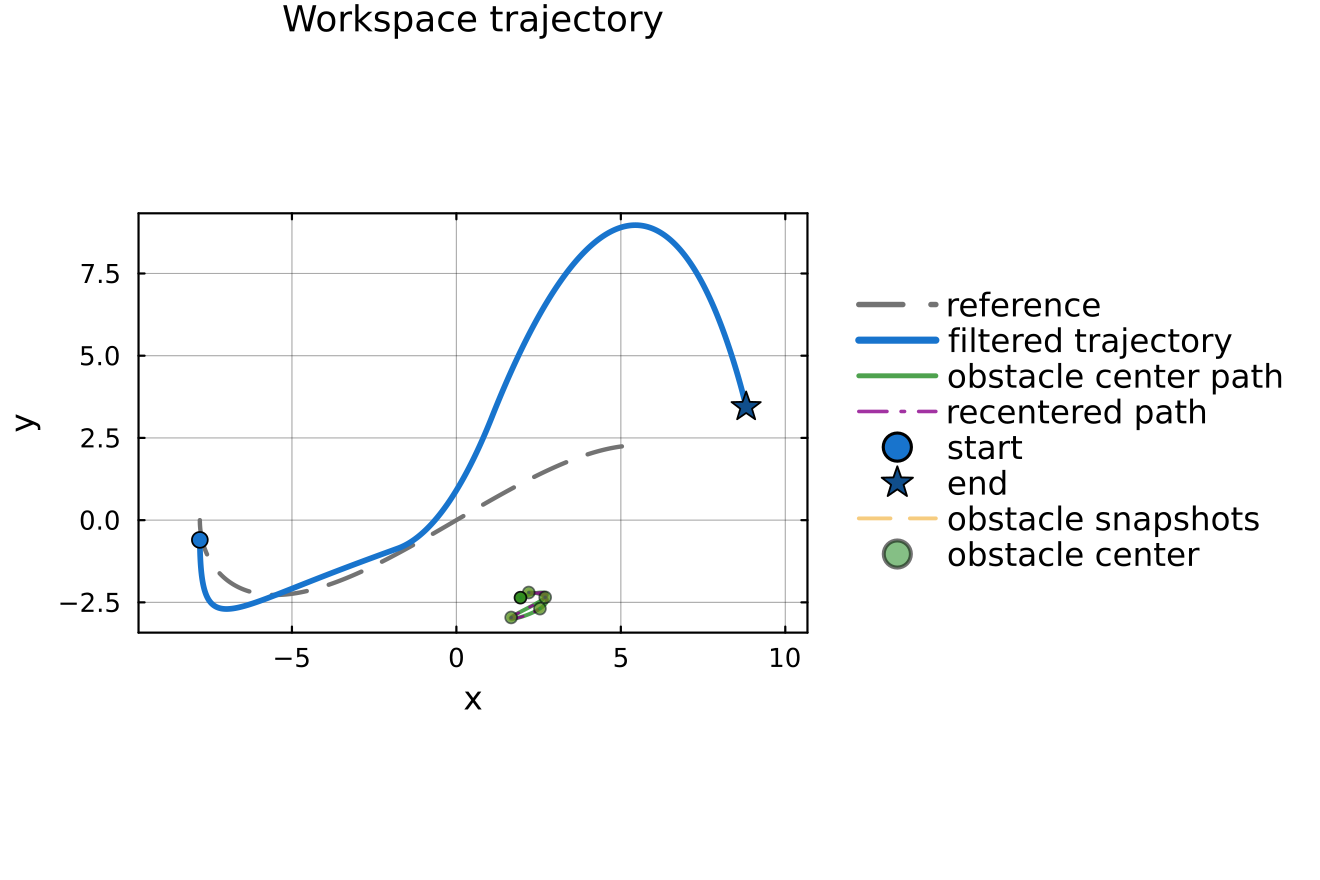

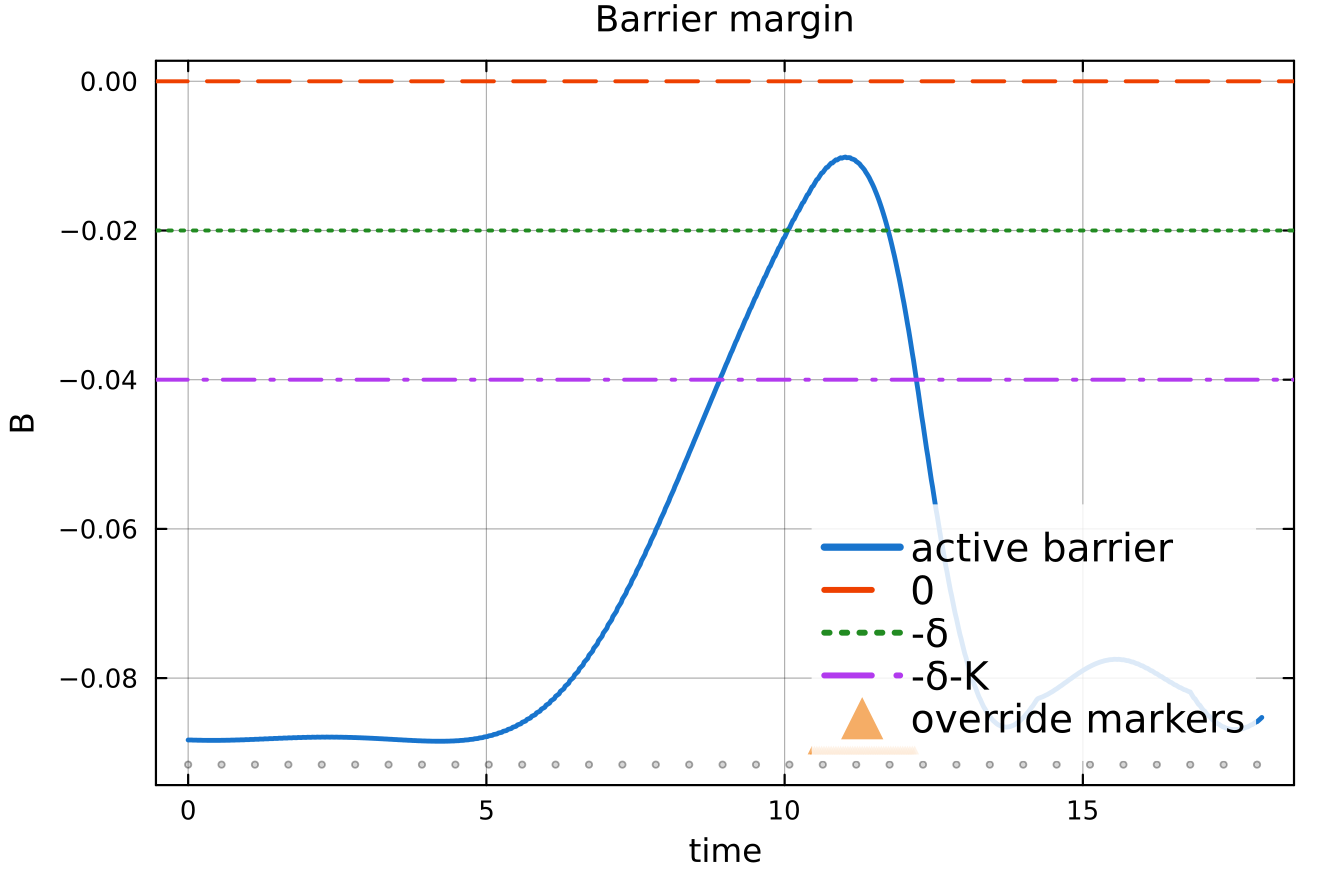

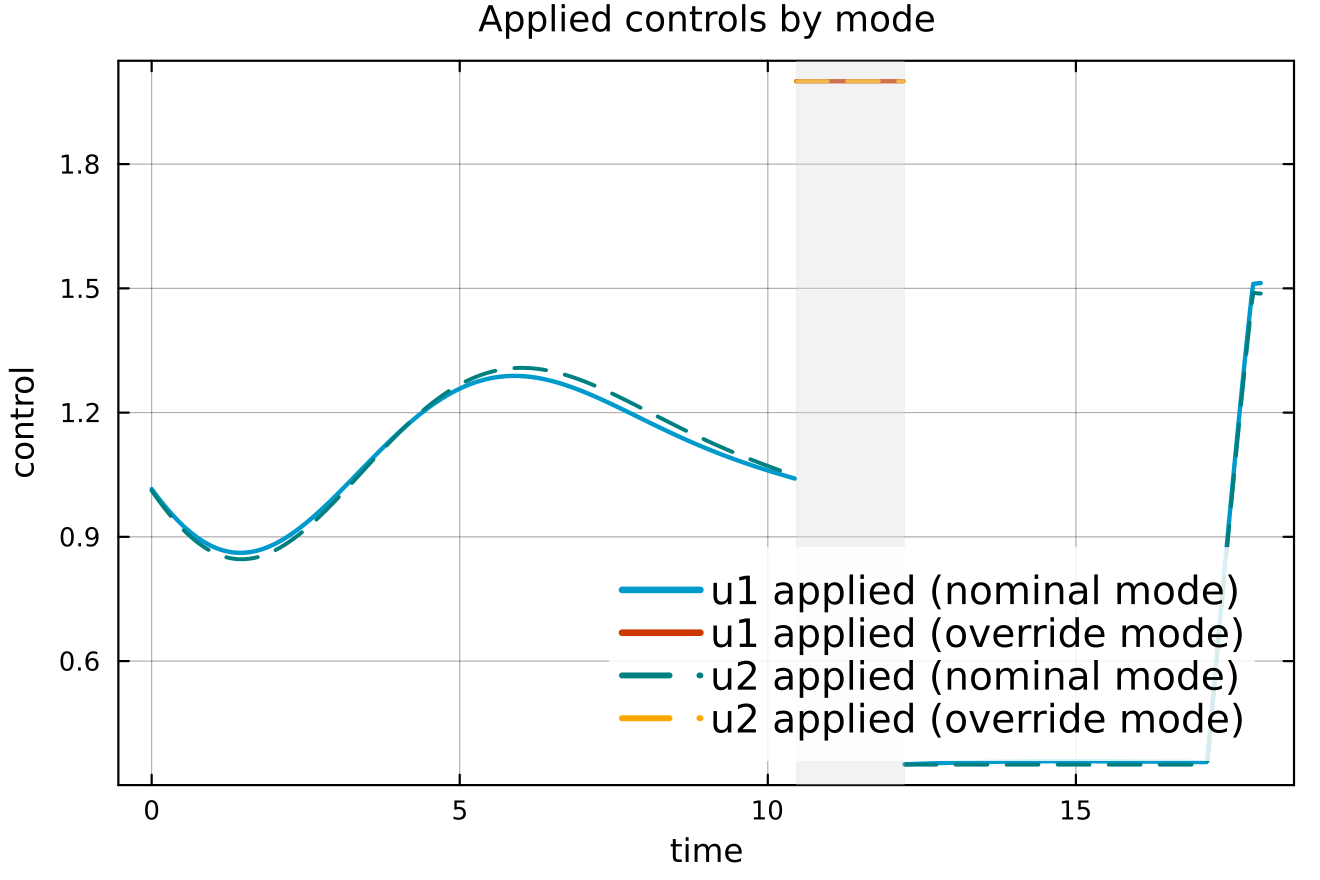

Selected runtime cfg: gated_soft (δ=0.02, K=0.02, Bth=-0.05, Bh=0.01, tau_steps=4)
Margin violations (B > -δ): 84
Override steps (total): 88 / 901
Override ratio: 0.098
Min distance to obstacle center: 3.8544 (radius = 0.1)
Mean tracking error: 2.626, max tracking error: 7.882
Collision detected (distance <= radius): false
Saved GIF: figures/repulsive_hybrid_planar_multirotor.gif


In [10]:
include("Repulsive_hybrid_planar_multirotor7D_recenter_fix.jl")
using Random
using Statistics

all_B_raw = all_barriers
U_sim = [Float64.(u) for u in barrier_controls_synth]

function sample_unsafe_pts_pm(n, r; vxlim=5.0, vylim=5.0, ωlim=4.0, elim=0.8)
    pts = Vector{Vector{Float64}}()
    for _ in 1:n
        ρ = r * sqrt(rand())
        θ = 2π * rand()
        px = ρ * cos(θ)
        py = ρ * sin(θ)
        vx = vxlim * (2rand() - 1.0)
        vy = vylim * (2rand() - 1.0)
        ang = π * (2rand() - 1.0)
        omg = ωlim * (2rand() - 1.0)
        err = elim * (2rand() - 1.0)
        push!(pts, [px, py, vx, vy, ang, omg, err])
    end
    return pts
end

Random.seed!(17)
unsafe_probe_pts = sample_unsafe_pts_pm(450, 0.098)
unsafe_floor = .001
shift_scale = 0.9

all_B = Polynomial[]
barrier_shift = Float64[]
for B in all_B_raw
    unsafe_vals = [B(pt...) for pt in unsafe_probe_pts]
    max_shift = minimum(unsafe_vals) - unsafe_floor
    s = max(0.0, shift_scale * max_shift)
    push!(barrier_shift, s)
    push!(all_B, B - s)
end
println("Barrier shift stats -> min: ", round(minimum(barrier_shift), digits=5), ", max: ", round(maximum(barrier_shift), digits=5), ", mean: ", round(mean(barrier_shift), digits=5))

# Coord-turn-like lazy8 profile, scaled to stay inside the planar multirotor workspace bounds.
traj_scale = 0.65
base_kwargs = (
    dt=0.02,
    T=18.0,
    x0=[-7.8, -0.6, 0.0, 0.0, 0.0, 0.0, 0.0],
    ref_style=:lazy8,
    ref_start=(-10.0 * traj_scale, -10.0 * traj_scale),
    ref_end=(10.0 * traj_scale, 10.0 * traj_scale),
    ref_T=22.0,
    lazy8_center=(0.0, 0.0),
    lazy8_scale=(12.0 * traj_scale, 7.0 * traj_scale),
    lazy8_cycles=0.45,
    lazy8_phase=-π/2,
    alpha=0.10,
    v_obs=(0.55, 0.40),
    x0_obs=(2.2, -2.6),
)

candidate_cfgs = [
    (name="no_override", delta=0.02, K=0.02, Bth=Inf, Bh=0.0, tau_steps=4, dist_trig=0.0, dist_rel=0.0),
    (name="gated_soft", delta=0.02, K=0.02, Bth=-0.050, Bh=0.010, tau_steps=4, dist_trig=4.2, dist_rel=5.0),
    (name="gated_med", delta=0.025, K=0.025, Bth=-0.045, Bh=0.010, tau_steps=4, dist_trig=4.0, dist_rel=4.8),
    (name="forced_override", delta=0.03, K=0.03, Bth=-0.090, Bh=0.010, tau_steps=4, dist_trig=Inf, dist_rel=Inf),
]

best_any = nothing
best_any_key = (Inf, Inf)
best_with_override = nothing
best_override_key = (Inf, Inf)

for cfg in candidate_cfgs
    res_try = RepulsiveHybridPlanarMultirotorRecenterFix.run_repulsive_hybrid_planar_multirotor_demo(
        Bs=all_B,
        U=U_sim,
        K=cfg.K,
        delta=cfg.delta,
        alpha=base_kwargs.alpha,
        tau_steps=cfg.tau_steps,
        override_B_threshold=cfg.Bth,
        override_B_hysteresis=cfg.Bh,
        override_dist_trigger=cfg.dist_trig,
        override_dist_release=cfg.dist_rel,
        strict_delta_enforcement=false,
        make_plots=false,
        dt=base_kwargs.dt,
        T=base_kwargs.T,
        x0=base_kwargs.x0,
        ref_style=base_kwargs.ref_style,
        ref_start=base_kwargs.ref_start,
        ref_end=base_kwargs.ref_end,
        ref_T=base_kwargs.ref_T,
        lazy8_center=base_kwargs.lazy8_center,
        lazy8_scale=base_kwargs.lazy8_scale,
        lazy8_cycles=base_kwargs.lazy8_cycles,
        lazy8_phase=base_kwargs.lazy8_phase,
        v_obs=base_kwargs.v_obs,
        x0_obs=base_kwargs.x0_obs,
        gif_file="figures/repulsive_hybrid_planar_multirotor.gif",
    )

    override_ratio = res_try.n_override / max(length(res_try.B_crit), 1)
    n_margin_violate = count(b -> b > -cfg.delta, res_try.B_crit)
    safety_penalty = max(0.0, 0.25 - res_try.min_dist_to_obs)
    collision_penalty = res_try.collision ? 1000.0 : 0.0
    score = collision_penalty + 160.0 * safety_penalty + 0.10 * res_try.mean_track_err + 1.5 * override_ratio
    key = (score, res_try.mean_track_err)

    println("candidate ", cfg.name, " -> overrides=", res_try.n_override, ", violations(B>-δ)=", n_margin_violate, ", override_ratio=", round(override_ratio, digits=3),
        ", minDist=", round(res_try.min_dist_to_obs, digits=3), ", meanTrack=", round(res_try.mean_track_err, digits=3),
        ", score=", round(score, digits=3))

    if key < best_any_key
        best_any = (cfg=cfg, res=res_try, n_violate=n_margin_violate, score=score, override_ratio=override_ratio)
        best_any_key = key
    end
    if res_try.n_override > 0 && key < best_override_key
        best_with_override = (cfg=cfg, res=res_try, n_violate=n_margin_violate, score=score, override_ratio=override_ratio)
        best_override_key = key
    end
end

if best_with_override === nothing
    @warn "No candidate produced override; falling back to overall best."
    best = best_any
else
    best = best_with_override
end

@assert best !== nothing "No runtime candidate produced results."

res = RepulsiveHybridPlanarMultirotorRecenterFix.run_repulsive_hybrid_planar_multirotor_demo(
    Bs=all_B,
    U=U_sim,
    K=best.cfg.K,
    delta=best.cfg.delta,
    alpha=base_kwargs.alpha,
    tau_steps=best.cfg.tau_steps,
    override_B_threshold=best.cfg.Bth,
    override_B_hysteresis=best.cfg.Bh,
    override_dist_trigger=best.cfg.dist_trig,
    override_dist_release=best.cfg.dist_rel,
    strict_delta_enforcement=false,
    make_plots=true,
    dt=base_kwargs.dt,
    T=base_kwargs.T,
    x0=base_kwargs.x0,
    ref_style=base_kwargs.ref_style,
    ref_start=base_kwargs.ref_start,
    ref_end=base_kwargs.ref_end,
    ref_T=base_kwargs.ref_T,
    lazy8_center=base_kwargs.lazy8_center,
    lazy8_scale=base_kwargs.lazy8_scale,
    lazy8_cycles=base_kwargs.lazy8_cycles,
    lazy8_phase=base_kwargs.lazy8_phase,
    v_obs=base_kwargs.v_obs,
    x0_obs=base_kwargs.x0_obs,
    gif_file="figures/repulsive_hybrid_planar_multirotor.gif",
)

display(res.p_traj)
display(res.p_B)
display(res.p_u)
println("Selected runtime cfg: ", best.cfg.name, " (δ=", best.cfg.delta, ", K=", best.cfg.K, ", Bth=", best.cfg.Bth, ", Bh=", best.cfg.Bh, ", tau_steps=", best.cfg.tau_steps, ")")
println("Margin violations (B > -δ): ", best.n_violate)
println("Override steps (total): ", res.n_override, " / ", length(res.B_crit))
println("Override ratio: ", round(res.n_override / length(res.B_crit), digits=3))
println("Min distance to obstacle center: ", round(res.min_dist_to_obs, digits=4), " (radius = ", base_kwargs.alpha, ")")
println("Mean tracking error: ", round(res.mean_track_err, digits=3), ", max tracking error: ", round(res.max_track_err, digits=3))
println("Collision detected (distance <= radius): ", res.collision)
println("Saved GIF: ", res.gif_path)